In [3]:
# %%
# %%
import os
import sys
import numpy as np
import torch
# from torch.utils.data import TensorDataset, DataLoader

# DL-Kit
sys.path.append('/Users/hgoldwyn/Research/projects/SR_CNN/dl-kit') #TODO adjust path
sys.path.append('/projects/ecrpstats/dl-kit') #TODO adjust path
from dlkit.log.log_util import (logging_set_up, logging_get_logger)
# from dlkit.nets.mlp import MLPModel
from dlkit.opt.train import train_epochs
from dlkit.nets.conv2d import Conv2dUpscaleModelInterpolate

## Load model module
sys.path.append('/Users/hgoldwyn/Research/projects/SR_CNN/paper_repo/auxilary_modules') #TODO adjust path
sys.path.append('/projects/ecrpstats/distributional_SRCNN/auxilary_modules')
import data_loading
import plotting

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pandas as pd

train_or_load = 'train'
# %%
hr_data_size = 64
lr_data_size = 8

# %%
epochs = 500
batch_size = 32
##
region = 0
subregion = 'all'

# %%
## import data
xtrainHR, xtestHR, xtrainLR, xtestLR = data_loading.import_data(
    region,
    subregion,
    train_fraction=.75, 
    order='(subregion, time)'
    )

failed to find data in /projects/...: [Errno 2] No such file or directory: '/projects/ecrpstats/distributional_SRCNN/data/subregions_wind_u_64x64.npy'


In [4]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [5]:
device = (
    "cuda"
    if torch.cuda.is_available()
    # else "mps"
    # if torch.backends.mps.is_available()
    else "cpu"
    )
print(f"Using device: {device}")

Using device: cpu


Define basis functions

In [6]:
N = 64
def compl_dft_basis(x, y, k_x, k_y):
    return np.exp(1j * 2*np.pi * (k_x*x + k_y*y)/N)

In [7]:
x = np.arange(0, N)

xg = np.tile(x, N)            # generates x-coordinates for the entire grid N*K 
yg = np.repeat(x, N, axis=0)

mat_xg = xg.reshape((64, 64))
mat_yg = yg.reshape((64, 64))

In [8]:
## Create basis functions to max period
# max_T = 20
# min_k = int(N/max_T)
min_k = 0
print(f"min k : {min_k}")
# max_k = (N)//2
max_k = (N)//2 + 1
print(f"max k : {max_k}")

basis_function_k_idx = []
basis_functions = []
for _kx in range(min_k, max_k):
    for _ky in range(min_k, max_k):
        basis_functions.append(
            compl_dft_basis(
                mat_xg, 
                mat_yg, 
                _kx, 
                _ky
                )
            )
        basis_function_k_idx.append((_kx, _ky))
        
basis_functions = np.asarray(basis_functions).reshape((-1, 64**2)).T
basis_functions.shape

min k : 0
max k : 33


(4096, 1089)

In [9]:
## Generate complex tensor
basis_functions_tensor = torch.tensor(basis_functions, dtype=torch.complex64).to(device)

In [10]:
p4p5_cov_params = np.load(
    "../stage_2/output/parCov_fitting_fourier_allImages_mseStart_globalPrior_anal_empPriorStdOn4p5_param_fits.npy"
    )

In [11]:

def get_r(x, y):
    return np.sqrt(np.subtract.outer(x, x)**2 +  np.subtract.outer(y, y)**2)


def pow_exp_correlation(r, a=1, alpha=1): 
    """ Powered exponential correlation
        a > 0
        0 < alpha < 2
        """
    c = torch.exp(-(r/a)**alpha)
    # c[r == 0] = 1e-8
    return c

def pow_exp_cov(r, sigma, tau, a, alpha):
    """
    """
    c_term = sigma**2 * pow_exp_correlation(r, a=a, alpha=alpha)
    if c_term.ndim == 2:
        tau_term = torch.diag_embed(torch.Tensor([tau]*len(c_term)))
    elif c_term.ndim == 1:
        tau_term = torch.zeros_like(c_term)
        tau_term[0] = tau
    
    return c_term + tau_term

# K = hr_data_size
K = 64
x = np.arange(0, K)
xg = np.tile(x, K)            # generates x-coordinates for the entire grid K*K 
yg = np.repeat(x, K, axis=0)
pixel_sep = get_r(xg, yg)


In [13]:
pixel_sep_rav = pixel_sep.ravel()

In [25]:
pixel_sep.shape

(4096, 4096)

In [27]:
import numpy as np
from scipy.fft import fft2, ifft2, fftshift

K = 64
Nmodes = basis_functions_tensor.shape[1]

# integer distance grid (once)
# separation grid (Δx, Δy)
dx = np.arange(-K//2, K//2)
dy = np.arange(-K//2, K//2)
DX, DY = np.meshgrid(dx, dy, indexing="ij")

r = np.sqrt(DX**2 + DY**2)
r_int = np.round(r).astype(int)

r_vals = np.unique(r_int)
nr = len(r_vals)

mode_response = np.zeros((nr, Nmodes), dtype=np.float64)

for k in range(Nmodes):
    # reshape spatial mode
    phi = basis_functions_tensor[:, k].reshape(K, K).cpu().numpy()

    # autocorrelation via FFT
    F = fft2(phi)
    ac = fftshift(ifft2(np.abs(F)**2).real)

    # radial average
    for i, rv in enumerate(r_vals):
        mask = (r_int == rv)
        mode_response[i, k] = ac[mask].mean()


In [28]:
r.shape

(64, 64)

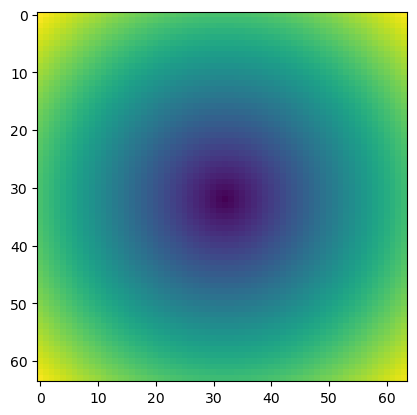

In [23]:
plt.imshow(r)

In [19]:
r_vals

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [15]:
cov_vs_r = p4p5_cov_params @ mode_response.T


In [17]:
cov_vs_r.shape

(642, 46)

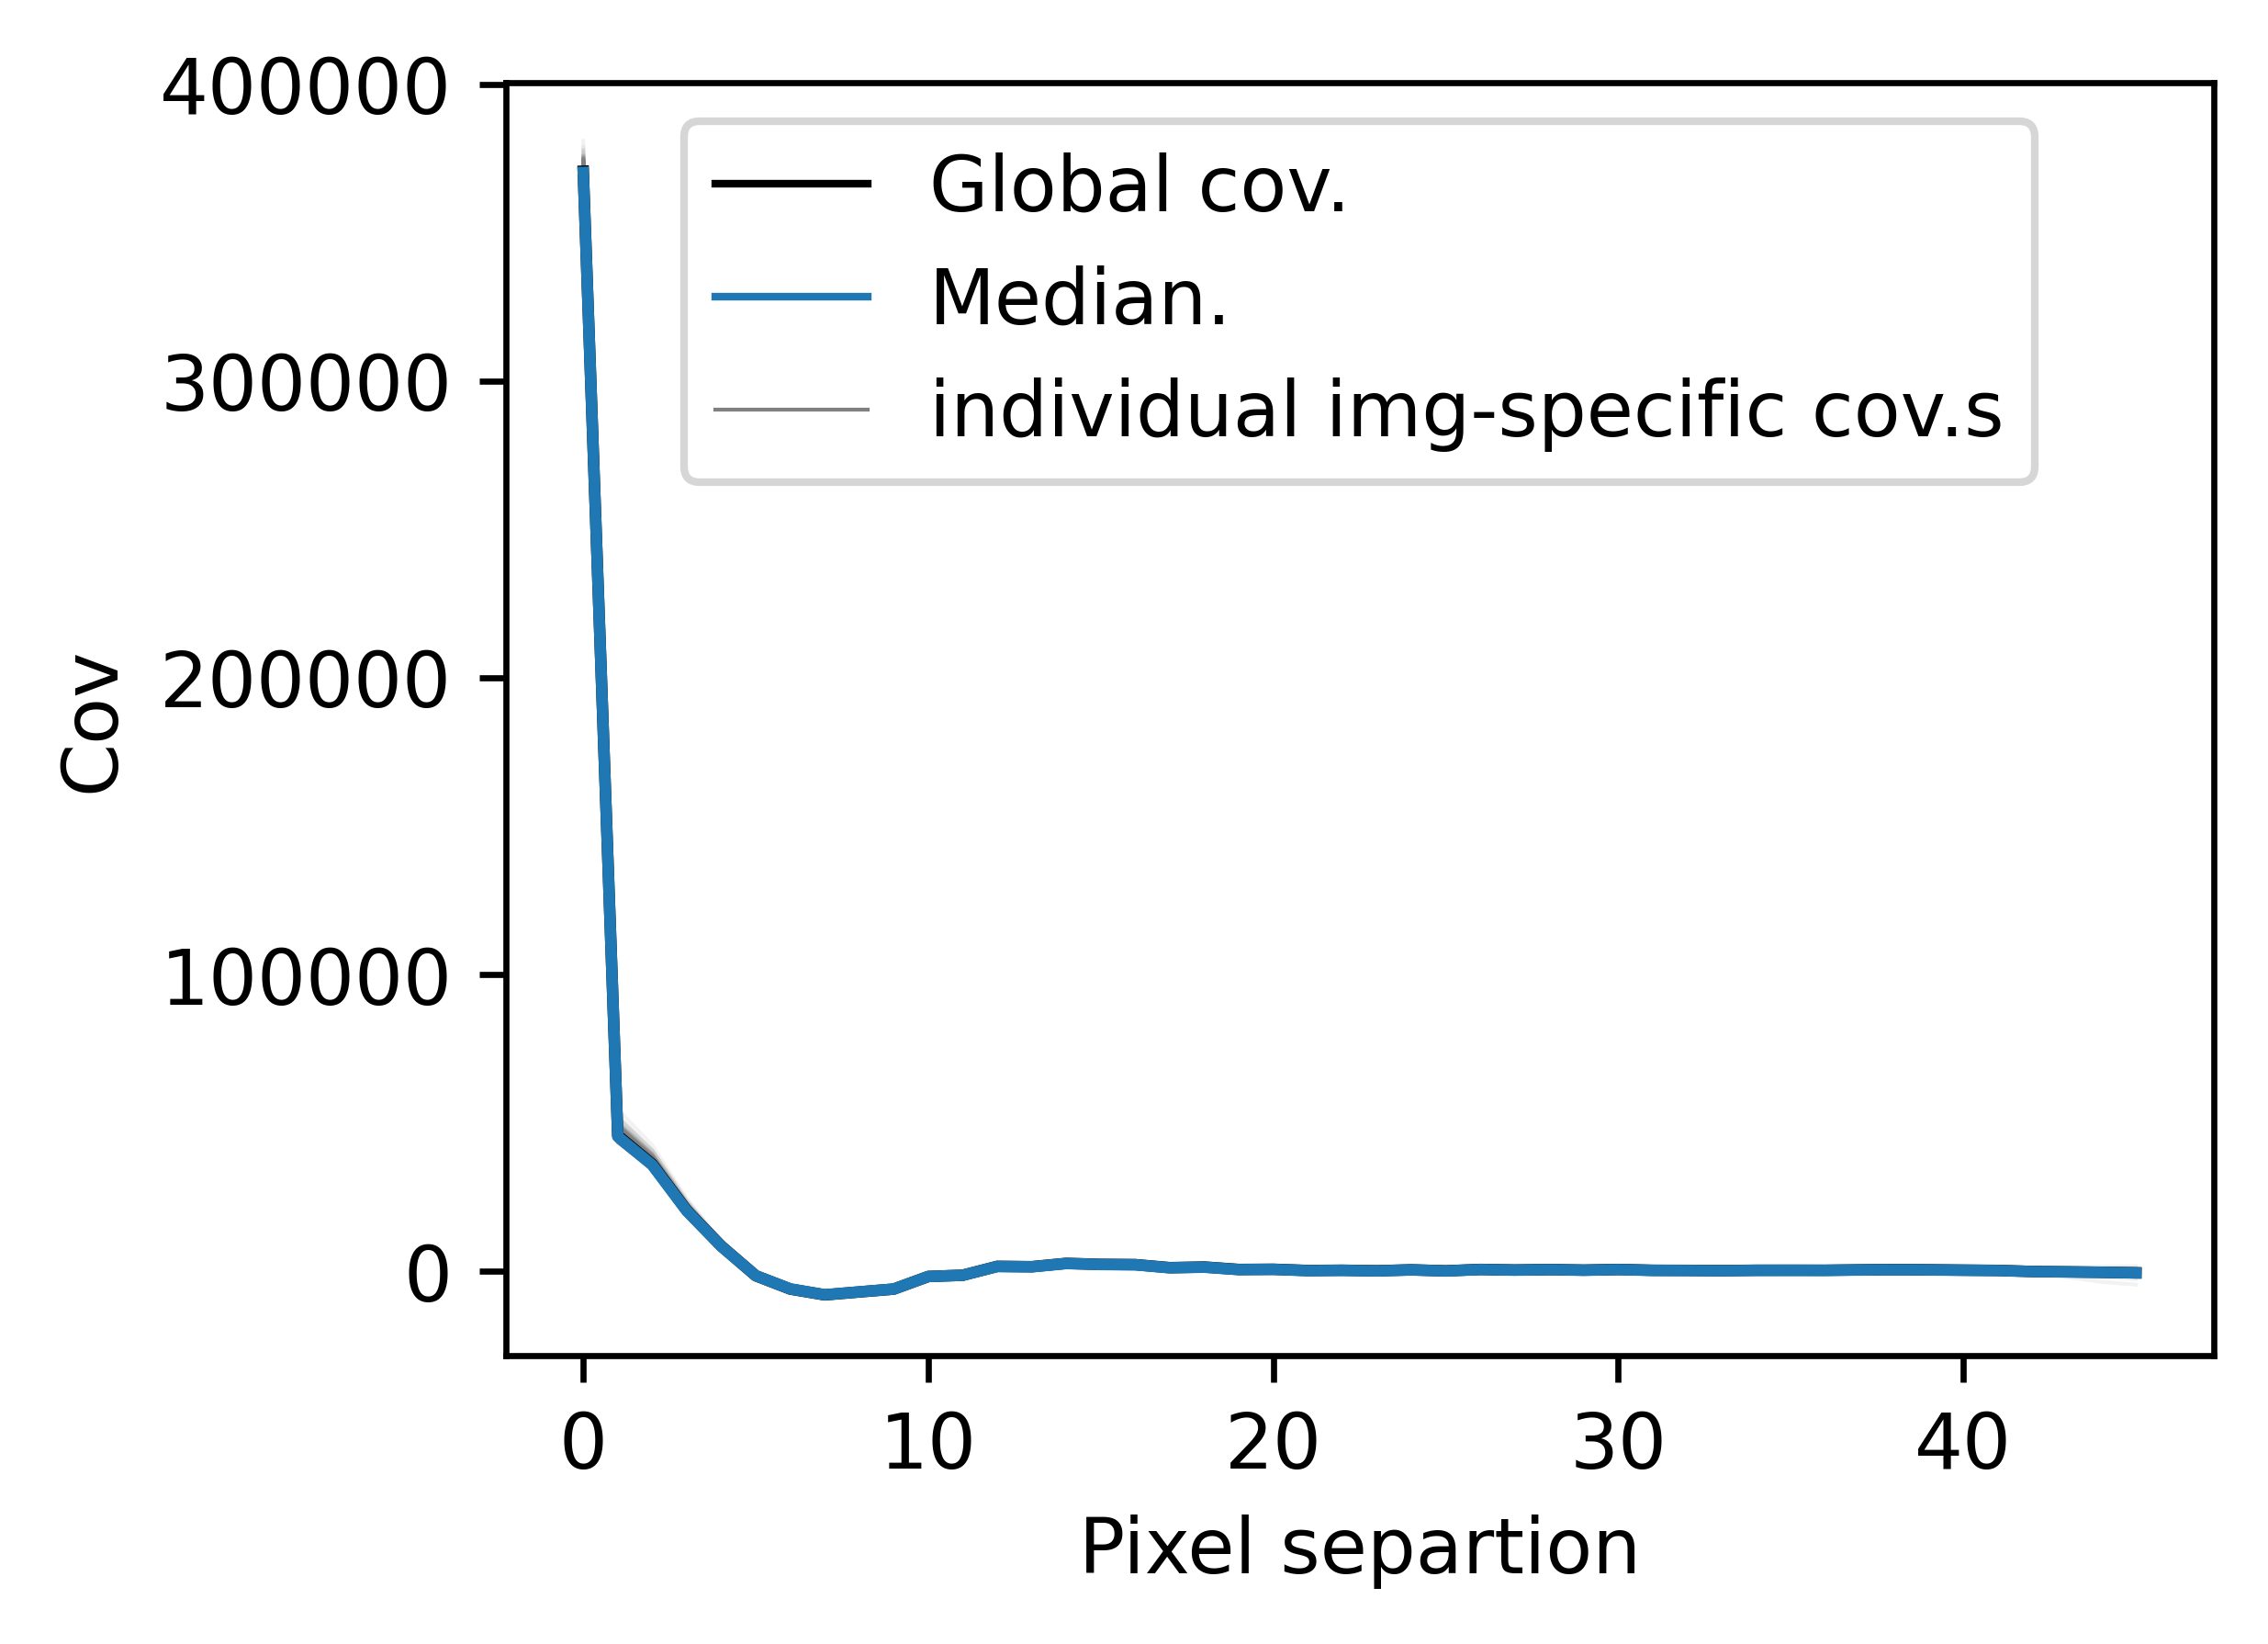

In [29]:
plt.figure(dpi=600, figsize=(4, 3))

# fit_params = minimized_params.detach()

plt.plot(r_vals, cov_vs_r.mean(axis=0), color='k', label='mean')
plt.plot(r_vals, np.median(cov_vs_r, axis=0), color='C0', label='median')

for i, cov in enumerate(cov_vs_r):
    if i == 0:
        _label = 'individual img-specific cov.s'
    else:
        _label = None
    plt.plot(r_vals, cov, alpha=0.1, color='gray', zorder = 0, lw=.5, label=_label)


plt.ylabel('Cov')
plt.xlabel('Pixel separtion')
# plt.legend()
# plt.ylim((-0.0025, 0.01))
# plt.ylim((-0.0004, 0.0008))

## ~~~ Legend ~~~
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

custom_handles = [
    Line2D([0], [0], color='black', linewidth=1, label='Global cov.'),
    Line2D([0], [0], color='C0', linewidth=1, label='Median.'),
    Line2D([], [], color='gray', linewidth=0.5, label='individual img-specific cov.s'),
]

plt.gca().legend(handles=custom_handles, loc='upper center', fontsize=10, frameon=True)
